✅ BASE_DIR   : /Users/pravallikachepuri/customer-churn-prediction
✅ DATA_DIR   : /Users/pravallikachepuri/customer-churn-prediction/data
✅ RESULTS_DIR: /Users/pravallikachepuri/customer-churn-prediction/results
✅ MODELS_DIR : /Users/pravallikachepuri/customer-churn-prediction/models

📌 X_train shape : (5634, 19)
📌 X_test shape  : (1409, 19)
[0]	validation_0-logloss:0.56503
[50]	validation_0-logloss:0.41672
[100]	validation_0-logloss:0.41560
[150]	validation_0-logloss:0.41841
[199]	validation_0-logloss:0.42029

✅ Accuracy : 0.7999
✅ ROC-AUC  : 0.8429

📌 Classification Report:
              precision    recall  f1-score   support

    No Churn       0.84      0.90      0.87      1035
       Churn       0.65      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409



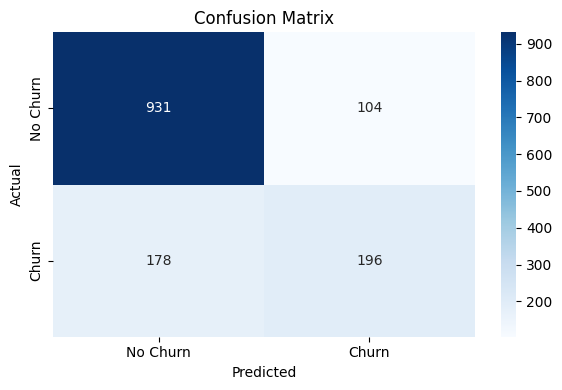

✅ Confusion matrix saved!


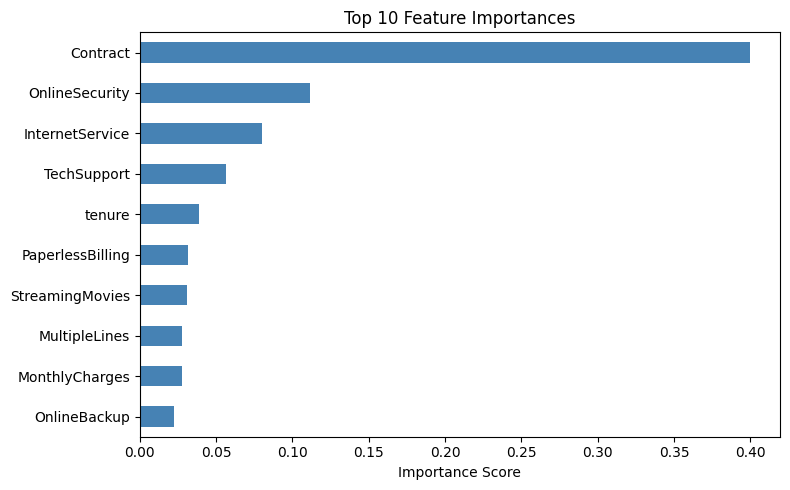

✅ Feature importance saved!

✅ Model saved!
📁 Model saved to : /Users/pravallikachepuri/customer-churn-prediction/models
📁 Charts saved to: /Users/pravallikachepuri/customer-churn-prediction/results


In [2]:
# ============================================================
# 🤖 NOTEBOOK 3 — XGBoost Model (Clean Version)
# ============================================================

import pandas as pd
import numpy as np
import os
import pickle
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (accuracy_score, roc_auc_score,
                              classification_report, confusion_matrix)

# ── Setup Paths ──────────────────────────────────────────────
BASE_DIR    = os.path.expanduser('~/customer-churn-prediction')
DATA_DIR    = os.path.join(BASE_DIR, 'data')
RESULTS_DIR = os.path.join(BASE_DIR, 'results')
MODELS_DIR  = os.path.join(BASE_DIR, 'models')

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR,  exist_ok=True)

print("✅ BASE_DIR   :", BASE_DIR)
print("✅ DATA_DIR   :", DATA_DIR)
print("✅ RESULTS_DIR:", RESULTS_DIR)
print("✅ MODELS_DIR :", MODELS_DIR)

# ── Load Processed Data ──────────────────────────────────────
X_train = pd.read_csv(os.path.join(DATA_DIR, 'X_train.csv')).values
X_test  = pd.read_csv(os.path.join(DATA_DIR, 'X_test.csv')).values
y_train = pd.read_csv(os.path.join(DATA_DIR, 'y_train.csv')).values.ravel()
y_test  = pd.read_csv(os.path.join(DATA_DIR, 'y_test.csv')).values.ravel()

print(f"\n📌 X_train shape : {X_train.shape}")
print(f"📌 X_test shape  : {X_test.shape}")

# ── Train XGBoost ────────────────────────────────────────────
model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)

# ── Evaluate ─────────────────────────────────────────────────
y_pred      = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:, 1]

print("\n" + "="*40)
print(f"✅ Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"✅ ROC-AUC  : {roc_auc_score(y_test, y_pred_prob):.4f}")
print("="*40)
print("\n📌 Classification Report:")
print(classification_report(y_test, y_pred,
      target_names=['No Churn', 'Churn']))

# ── Confusion Matrix ─────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'confusion_matrix.png'))
plt.show()
print("✅ Confusion matrix saved!")

# ── Feature Importance ───────────────────────────────────────
feat_names = ['gender', 'SeniorCitizen', 'Partner', 'Dependents',
              'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
              'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
              'TechSupport', 'StreamingTV', 'StreamingMovies',
              'Contract', 'PaperlessBilling', 'PaymentMethod',
              'MonthlyCharges', 'TotalCharges']

importances = pd.Series(model.feature_importances_, index=feat_names)
importances.sort_values().tail(10).plot(kind='barh', figsize=(8, 5),
                                         color='steelblue')
plt.title('Top 10 Feature Importances')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'feature_importance.png'))
plt.show()
print("✅ Feature importance saved!")

# ── Save Model ───────────────────────────────────────────────
with open(os.path.join(MODELS_DIR, 'xgb_churn_model.pkl'), 'wb') as f:
    pickle.dump(model, f)

print("\n✅ Model saved!")
print(f"📁 Model saved to : {MODELS_DIR}")
print(f"📁 Charts saved to: {RESULTS_DIR}")